In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

1. 데이터 불러오기

In [136]:
df = pd.read_csv(r"C:\Users\82105\OneDrive\바탕 화면\기계학습\weight_change_dataset.csv", encoding="cp949") #"weight_change_dataset.csv

2. 데이터 파악

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Participant ID                 100 non-null    int64  
 1   Age                            100 non-null    int64  
 2   Gender                         100 non-null    object 
 3   Current Weight (lbs)           100 non-null    float64
 4   BMR (Calories)                 100 non-null    float64
 5   Daily Calories Consumed        100 non-null    float64
 6   Daily Caloric Surplus/Deficit  100 non-null    float64
 7   Weight Change (lbs)            100 non-null    float64
 8   Duration (weeks)               100 non-null    int64  
 9   Physical Activity Level        100 non-null    object 
 10  Sleep Quality                  100 non-null    object 
 11  Stress Level                   100 non-null    int64  
 12  Final Weight (lbs)             100 non-null    floa

In [138]:
df.dtypes

Participant ID                     int64
Age                                int64
Gender                            object
Current Weight (lbs)             float64
BMR (Calories)                   float64
Daily Calories Consumed          float64
Daily Caloric Surplus/Deficit    float64
Weight Change (lbs)              float64
Duration (weeks)                   int64
Physical Activity Level           object
Sleep Quality                     object
Stress Level                       int64
Final Weight (lbs)               float64
dtype: object

In [139]:
df.rename(columns={'Current Weight (lbs)':"Current Weight", 'BMR (Calories)':"BMR",
       'Weight Change (lbs)':"Weight Change", 'Duration (weeks)':"Duration",
       'Final Weight (lbs)':"Final Weight"
       },inplace=True)

(1) 종속 변수(Weight Change) 탐색

In [140]:
df["Weight Change"].describe()

count    100.000000
mean      -2.779817
std        7.443719
min      -35.678115
25%       -5.012312
50%        0.100000
75%        1.850000
max        5.000000
Name: Weight Change, dtype: float64

Text(0, 0.5, 'Frequency')

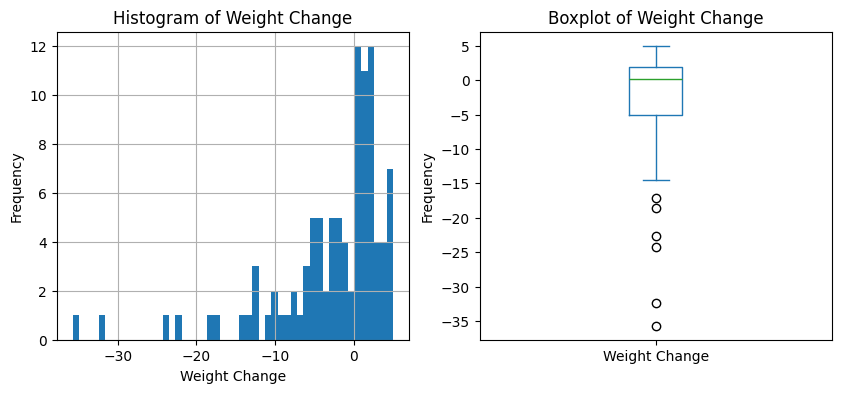

In [141]:
# Weight Change
fig, axes = plt.subplots(1, 2, figsize = (10,4))

#Weight Change 히스토그램
df["Weight Change"].hist(bins=50, ax = axes[0])
axes[0].set_title("Histogram of Weight Change")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Weight Change")

#Weight Change 박스플롯
df["Weight Change"].plot(kind = 'box', ax = axes[1])
axes[1].set_title("Boxplot of Weight Change")
axes[1].set_ylabel("Frequency")

In [142]:
#Weight Change의 이상치
q1 = df['Weight Change'].quantile(0.25)
q3 = df['Weight Change'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

df_outliers = df[(df['Weight Change'] < lower_bound) | 
                        (df['Weight Change'] > upper_bound)]

df_outliers

,Participant ID,Age,Gender,Current Weight,BMR,Daily Calories Consumed,Daily Caloric Surplus/Deficit,Weight Change,Duration,Physical Activity Level,Sleep Quality,Stress Level,Final Weight
7,8,40,M,207.9,2977.9,4000.0,1022.1,-35.678115,11,Moderately Active,Poor,9,172.2
24,25,39,M,163.6,2539.5,3355.7,816.3,-22.609479,12,Lightly Active,Poor,9,141.0
37,38,35,M,195.7,2881.0,4000.0,1119.0,-32.342605,10,Moderately Active,Poor,8,163.4
50,51,34,M,151.2,2441.1,3179.8,738.8,-18.539995,8,Lightly Active,Poor,8,132.7
78,79,46,F,182.5,2446.9,4000.0,1553.1,-24.190068,11,Very Active,Poor,8,158.3
85,86,18,M,182.4,2832.8,4000.0,1167.2,-17.150131,12,Moderately Active,Poor,8,165.2


(2) 독립 변수 탐색

- 수치형 변수

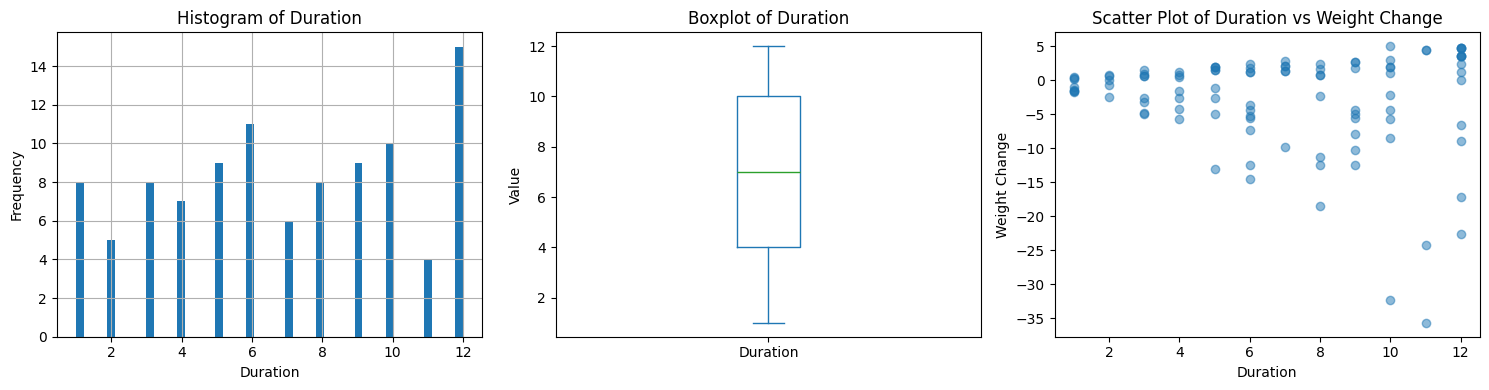

count    100.000000
mean       6.920000
std        3.515277
min        1.000000
25%        4.000000
50%        7.000000
75%       10.000000
max       12.000000
Name: Duration, dtype: float64

In [143]:
# 1.Duration
# 체중 변화를 측정하는 기간
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Duration의 막대 그래프
df["Duration"].hist(bins=50, ax = axes[0])
axes[0].set_title("Histogram of Duration")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Duration")

# Duration의 박스플롯
df["Duration"].plot(kind='box', ax=axes[1])
axes[1].set_title("Boxplot of Duration")
axes[1].set_ylabel("Value")

# Duration과 Weight Change 간의 산점도
axes[2].scatter(df["Duration"], df["Weight Change"], alpha=0.5)
axes[2].set_title("Scatter Plot of Duration vs Weight Change")
axes[2].set_xlabel("Duration")
axes[2].set_ylabel("Weight Change")

plt.tight_layout()
plt.show()

df['Duration'].describe()

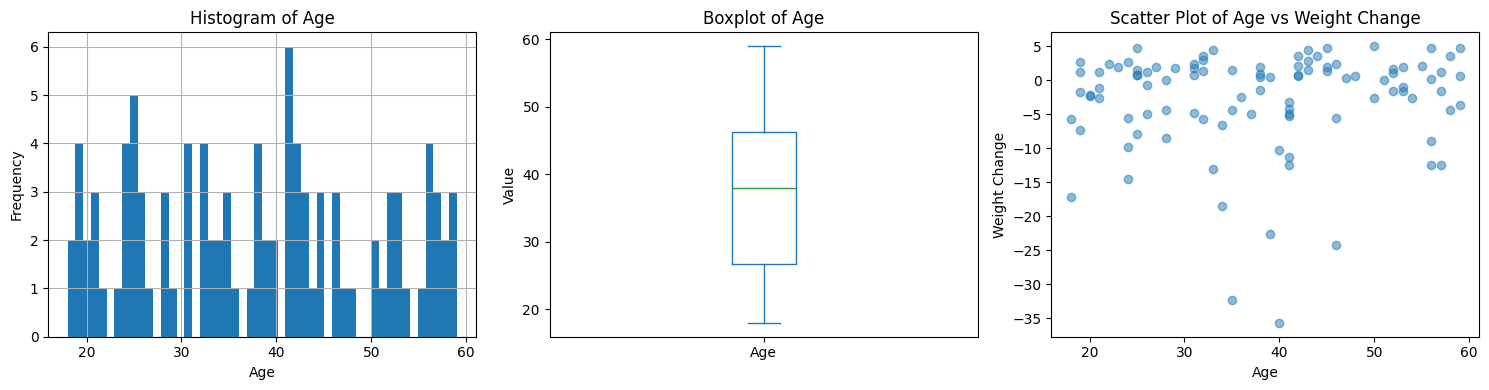

count    100.000000
mean      37.910000
std       12.219454
min       18.000000
25%       26.750000
50%       38.000000
75%       46.250000
max       59.000000
Name: Age, dtype: float64

In [144]:
# 2.Age
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age의 막대 그래프
df["Age"].hist(bins=50, ax = axes[0])
axes[0].set_title("Histogram of Age")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Age")

# Age의 박스플롯
df["Age"].plot(kind='box', ax=axes[1])
axes[1].set_title("Boxplot of Age")
axes[1].set_ylabel("Value")

# Age와 Weight Change 간의 산점도
axes[2].scatter(df["Age"], df["Weight Change"], alpha=0.5)
axes[2].set_title("Scatter Plot of Age vs Weight Change")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Weight Change")

plt.tight_layout()
plt.show()

df['Age'].describe()

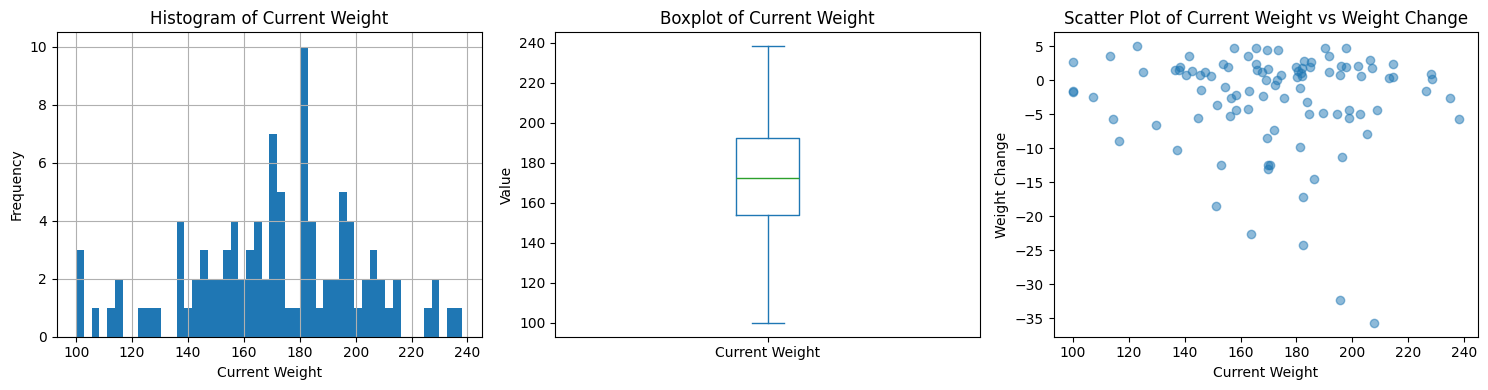

count    100.000000
mean     171.533000
std       30.333856
min      100.000000
25%      153.650000
50%      172.150000
75%      192.475000
max      238.200000
Name: Current Weight, dtype: float64

In [145]:
# 3.Current Weight
# 연구 시작 시점에서 참가자의 체중
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Current Weight의 막대 그래프
df["Current Weight"].hist(bins=50, ax = axes[0])
axes[0].set_title("Histogram of Current Weight")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Current Weight")

# Current Weight의 박스플롯
df["Current Weight"].plot(kind='box', ax=axes[1])
axes[1].set_title("Boxplot of Current Weight")
axes[1].set_ylabel("Value")

# Current Weight와 Weight Change 간의 산점도
axes[2].scatter(df["Current Weight"], df["Weight Change"], alpha=0.5)
axes[2].set_title("Scatter Plot of Current Weight vs Weight Change")
axes[2].set_xlabel("Current Weight")
axes[2].set_ylabel("Weight Change")

plt.tight_layout()
plt.show()

df['Current Weight'].describe()

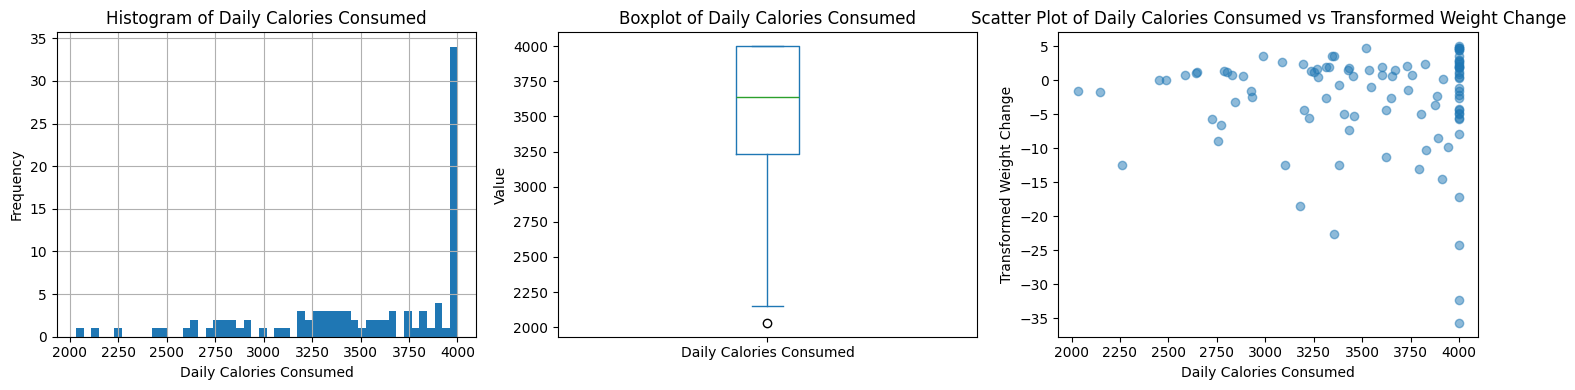

count     100.000000
mean     3518.292000
std       513.313097
min      2030.900000
25%      3233.300000
50%      3636.050000
75%      4000.000000
max      4000.000000
Name: Daily Calories Consumed, dtype: float64

In [146]:
# 4.Daily Calories Consumed
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# BMR의 막대 그래프
df["Daily Calories Consumed"].hist(bins=50, ax = axes[0])
axes[0].set_title("Histogram of Daily Calories Consumed")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Daily Calories Consumed")

# Daily Calories Consumed의 박스플롯
df["Daily Calories Consumed"].plot(kind='box', ax=axes[1])
axes[1].set_title("Boxplot of Daily Calories Consumed")
axes[1].set_ylabel("Value")

# Daily Calories Consumed과 Weight Change 간의 산점도
axes[2].scatter(df["Daily Calories Consumed"], df["Weight Change"], alpha=0.5)
axes[2].set_title("Scatter Plot of Daily Calories Consumed vs Transformed Weight Change")
axes[2].set_xlabel("Daily Calories Consumed")
axes[2].set_ylabel("Transformed Weight Change")

plt.tight_layout()
plt.show()

df['Daily Calories Consumed'].describe()

In [147]:
q1 = df['Daily Calories Consumed'].quantile(0.25)
q3 = df['Daily Calories Consumed'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

df_outliers = df[(df['Daily Calories Consumed'] < lower_bound) | 
                        (df['Daily Calories Consumed'] > upper_bound)]

df_outliers

,Participant ID,Age,Gender,Current Weight,BMR,Daily Calories Consumed,Daily Caloric Surplus/Deficit,Weight Change,Duration,Physical Activity Level,Sleep Quality,Stress Level,Final Weight
70,71,57,F,100.0,1566.5,2030.9,464.4,-1.658347,1,Lightly Active,Good,9,98.3


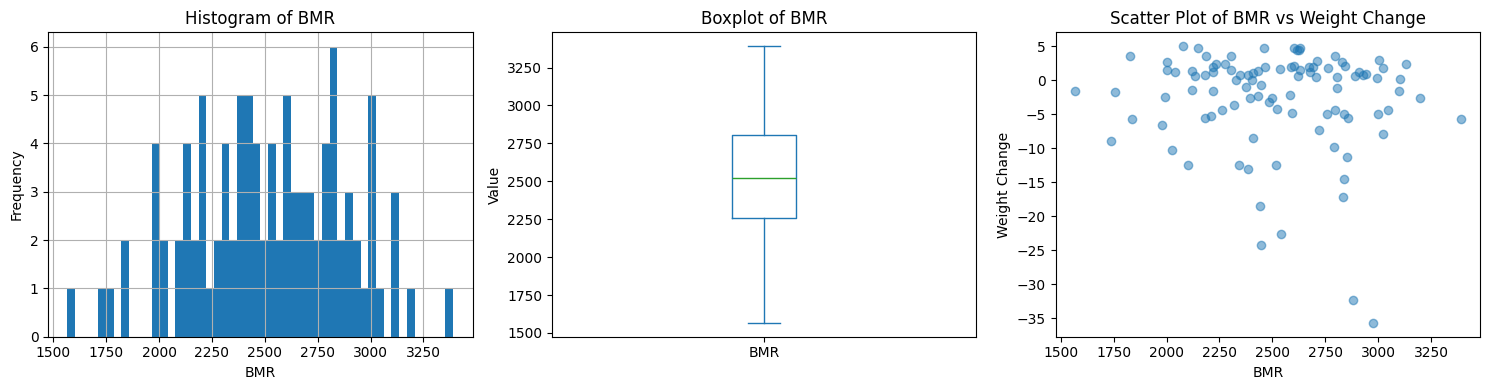

count     100.000000
mean     2518.206000
std       364.431221
min      1566.500000
25%      2255.050000
50%      2519.500000
75%      2805.975000
max      3390.800000
Name: BMR, dtype: float64

In [148]:
# 5.BMR
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# BMR의 막대 그래프
df["BMR"].hist(bins=50, ax = axes[0])
axes[0].set_title("Histogram of BMR")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("BMR")

# BMR의 박스플롯
df["BMR"].plot(kind='box', ax=axes[1])
axes[1].set_title("Boxplot of BMR")
axes[1].set_ylabel("Value")

# BMR과 Weight Change 간의 산점도
axes[2].scatter(df["BMR"], df["Weight Change"], alpha=0.5)
axes[2].set_title("Scatter Plot of BMR vs Weight Change")
axes[2].set_xlabel("BMR")
axes[2].set_ylabel("Weight Change")

plt.tight_layout()
plt.show()

df['BMR'].describe()

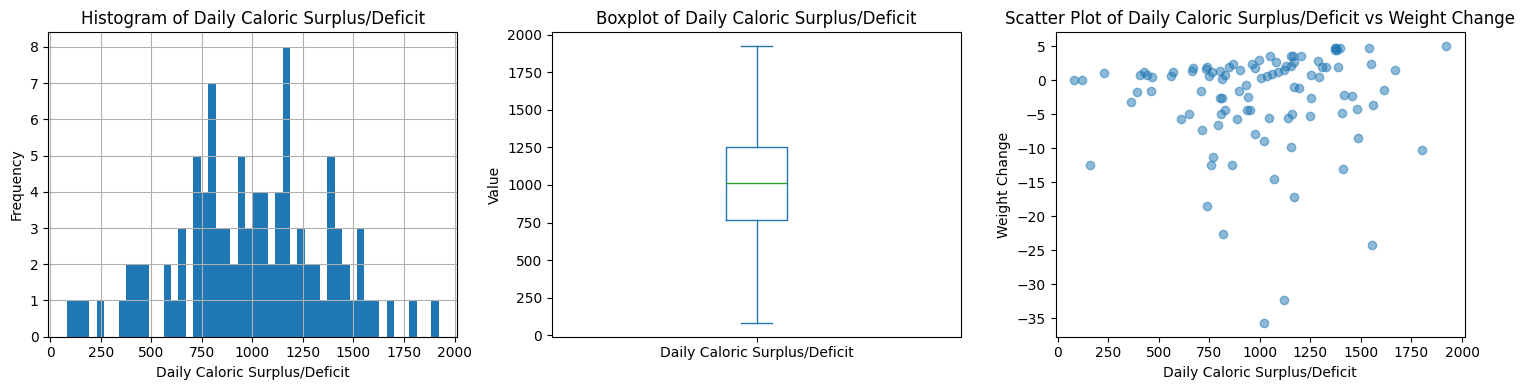

count     100.000000
mean     1000.091000
std       371.560827
min        82.500000
25%       766.950000
50%      1013.100000
75%      1253.325000
max      1922.500000
Name: Daily Caloric Surplus/Deficit, dtype: float64

In [149]:
# 6.Daily Caloric Surplus/Deficit
# Daily Caloric Consumed 와 BMR 간의 차이
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Daily Caloric Surplus/Deficit의 막대 그래프
df["Daily Caloric Surplus/Deficit"].hist(bins=50, ax = axes[0])
axes[0].set_title("Histogram of Daily Caloric Surplus/Deficit")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Daily Caloric Surplus/Deficit")

# Daily Caloric Surplus/Deficit의 박스플롯
df["Daily Caloric Surplus/Deficit"].plot(kind='box', ax=axes[1])
axes[1].set_title("Boxplot of Daily Caloric Surplus/Deficit")
axes[1].set_ylabel("Value")

# Daily Caloric Surplus/Deficit와 Weight Change 간의 산점도
axes[2].scatter(df["Daily Caloric Surplus/Deficit"], df["Weight Change"], alpha=0.5)
axes[2].set_title("Scatter Plot of Daily Caloric Surplus/Deficit vs Weight Change")
axes[2].set_xlabel("Daily Caloric Surplus/Deficit")
axes[2].set_ylabel("Weight Change")

plt.tight_layout()
plt.show()

df['Daily Caloric Surplus/Deficit'].describe()

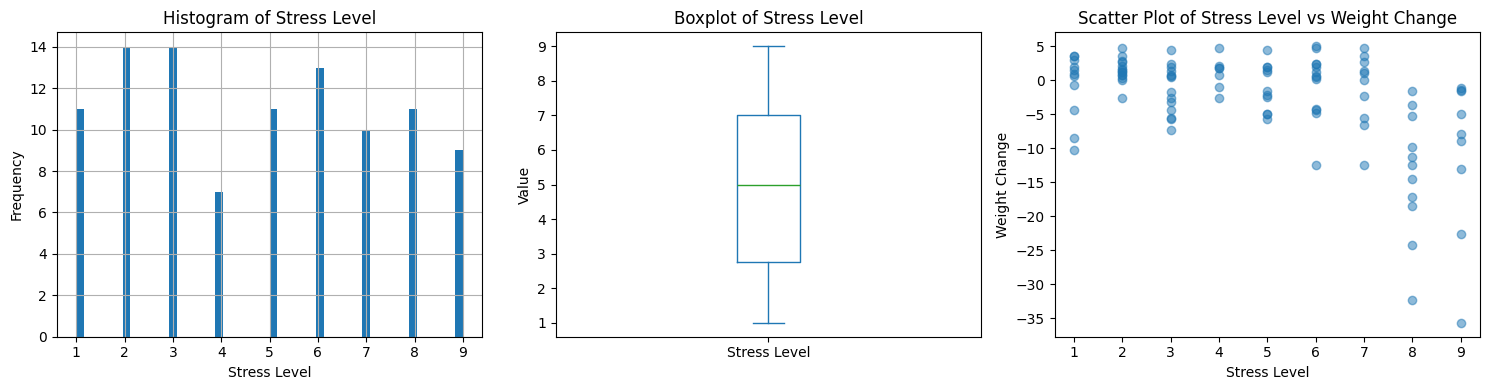

count    100.000000
mean       4.810000
std        2.576879
min        1.000000
25%        2.750000
50%        5.000000
75%        7.000000
max        9.000000
Name: Stress Level, dtype: float64

In [150]:
# 5.Stress Level 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Stress Level의 막대 그래프
df["Stress Level"].hist(bins=50, ax = axes[0])
axes[0].set_title("Histogram of Stress Level")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Stress Level")

# Stress Level의 박스플롯
df["Stress Level"].plot(kind='box', ax=axes[1])
axes[1].set_title("Boxplot of Stress Level")
axes[1].set_ylabel("Value")

# Stress Level과 Weight Change 간의 산점도
axes[2].scatter(df["Stress Level"], df["Weight Change"], alpha=0.5)
axes[2].set_title("Scatter Plot of Stress Level vs Weight Change")
axes[2].set_xlabel("Stress Level")
axes[2].set_ylabel("Weight Change")

plt.tight_layout()
plt.show()

df['Stress Level'].describe()

- 범주형 변수

C:\Users\82105\AppData\Local\Temp\ipykernel_15264\774482563.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='Weight Change', order = order_dict[feature], palette = 'Pastel1')


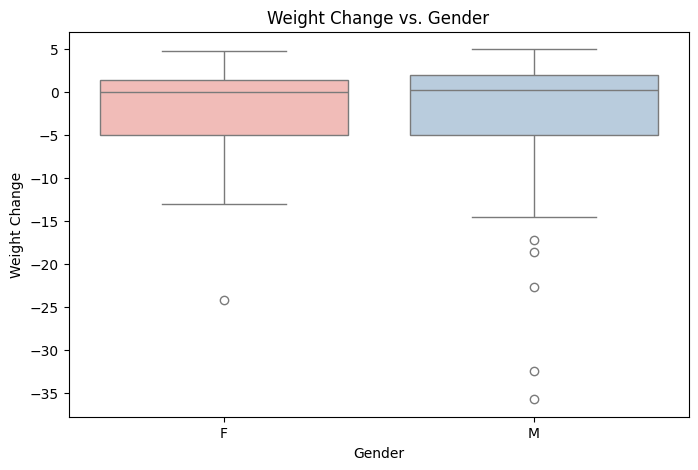

C:\Users\82105\AppData\Local\Temp\ipykernel_15264\774482563.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='Weight Change', order = order_dict[feature], palette = 'Pastel1')


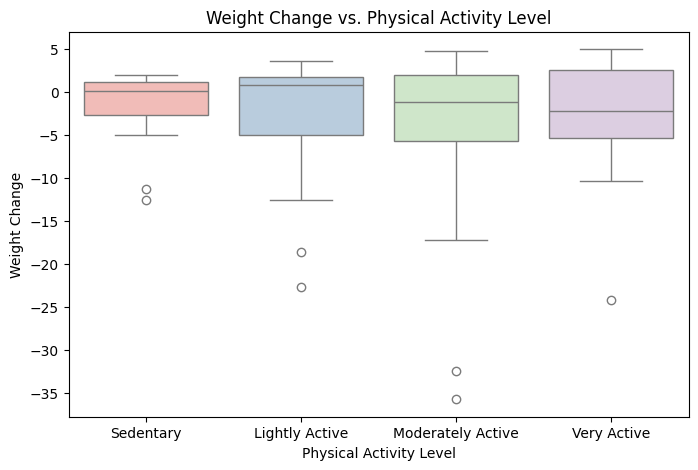

C:\Users\82105\AppData\Local\Temp\ipykernel_15264\774482563.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature, y='Weight Change', order = order_dict[feature], palette = 'Pastel1')


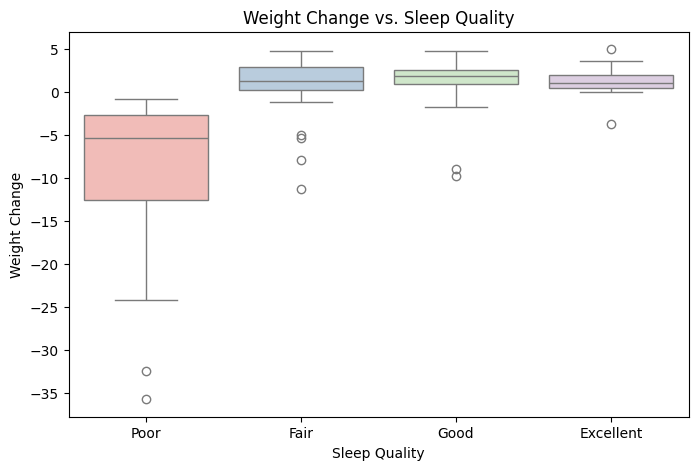

In [151]:
# 범주형 변수 박스 플롯
categorical_variables = ['Gender', 'Physical Activity Level', 'Sleep Quality']

order_dict = {
    'Gender' : ['F', 'M'],
    'Physical Activity Level' : ['Sedentary', 'Lightly Active', 'Moderately Active', 'Very Active'],
    'Sleep Quality' : ['Poor', 'Fair', 'Good', 'Excellent']
}

for feature in categorical_variables:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=feature, y='Weight Change', order = order_dict[feature], palette = 'Pastel1')
    plt.title(f'Weight Change vs. {feature}')
    plt.xlabel(feature)
    plt.ylabel('Weight Change')
    plt.show()

In [152]:
def get_outliers(df, feature, target):
    outliers = pd.DataFrame()
    # 각 범주별로 이상치를 찾기 위한 반복문
    for category in df[feature].unique():
        category_data = df[df[feature] == category][target]
        
        Q1 = category_data.quantile(0.25)
        Q3 = category_data.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 이상치 데이터 추출
        outlier_data = df[(df[feature] == category) & 
                          ((df[target] < lower_bound) | (df[target] > upper_bound))]
        
        outliers = pd.concat([outliers, outlier_data])
    
    return outliers

# 각 범주형 변수에 대해 이상치를 확인하는 코드
for feature in categorical_variables:
    outliers = get_outliers(df, feature, 'Weight Change')
    print(f"Feature: {feature}, Number of Outliers: {len(outliers)}")
    if len(outliers) > 0:
        display(outliers)

Feature: Gender, Number of Outliers: 6


,Participant ID,Age,Gender,Current Weight,BMR,Daily Calories Consumed,Daily Caloric Surplus/Deficit,Weight Change,Duration,Physical Activity Level,Sleep Quality,Stress Level,Final Weight
7,8,40,M,207.9,2977.9,4000.0,1022.1,-35.678115,11,Moderately Active,Poor,9,172.2
24,25,39,M,163.6,2539.5,3355.7,816.3,-22.609479,12,Lightly Active,Poor,9,141.0
37,38,35,M,195.7,2881.0,4000.0,1119.0,-32.342605,10,Moderately Active,Poor,8,163.4
50,51,34,M,151.2,2441.1,3179.8,738.8,-18.539995,8,Lightly Active,Poor,8,132.7
85,86,18,M,182.4,2832.8,4000.0,1167.2,-17.150131,12,Moderately Active,Poor,8,165.2
78,79,46,F,182.5,2446.9,4000.0,1553.1,-24.190068,11,Very Active,Poor,8,158.3


Feature: Physical Activity Level, Number of Outliers: 7


,Participant ID,Age,Gender,Current Weight,BMR,Daily Calories Consumed,Daily Caloric Surplus/Deficit,Weight Change,Duration,Physical Activity Level,Sleep Quality,Stress Level,Final Weight
5,6,56,F,152.9,2100.6,2262.4,161.9,-12.513498,9,Sedentary,Poor,6,140.4
87,88,41,M,196.2,2855.4,3623.3,767.9,-11.250015,8,Sedentary,Fair,8,184.9
78,79,46,F,182.5,2446.9,4000.0,1553.1,-24.190068,11,Very Active,Poor,8,158.3
24,25,39,M,163.6,2539.5,3355.7,816.3,-22.609479,12,Lightly Active,Poor,9,141.0
50,51,34,M,151.2,2441.1,3179.8,738.8,-18.539995,8,Lightly Active,Poor,8,132.7
7,8,40,M,207.9,2977.9,4000.0,1022.1,-35.678115,11,Moderately Active,Poor,9,172.2
37,38,35,M,195.7,2881.0,4000.0,1119.0,-32.342605,10,Moderately Active,Poor,8,163.4


Feature: Sleep Quality, Number of Outliers: 10


,Participant ID,Age,Gender,Current Weight,BMR,Daily Calories Consumed,Daily Caloric Surplus/Deficit,Weight Change,Duration,Physical Activity Level,Sleep Quality,Stress Level,Final Weight
27,28,59,M,151.4,2318.0,3877.8,1559.8,-3.678736,6,Very Active,Excellent,8,147.7
93,94,50,M,122.9,2077.5,4000.0,1922.5,5.000000,10,Very Active,Excellent,6,127.9
33,34,24,M,181.3,2792.2,3944.2,1152.0,-9.771601,7,Lightly Active,Good,8,171.5
96,97,56,F,116.5,1736.5,2756.5,1020.0,-8.923090,12,Moderately Active,Good,9,107.6
44,45,37,M,184.5,2758.3,3406.3,647.9,-4.988028,3,Sedentary,Fair,9,179.5
67,68,25,M,205.1,3024.3,4000.0,975.7,-7.886332,9,Very Active,Fair,9,197.2
74,75,41,F,156.1,2207.7,3458.1,1250.4,-5.269543,6,Moderately Active,Fair,8,150.8
87,88,41,M,196.2,2855.4,3623.3,767.9,-11.250015,8,Sedentary,Fair,8,184.9
7,8,40,M,207.9,2977.9,4000.0,1022.1,-35.678115,11,Moderately Active,Poor,9,172.2
37,38,35,M,195.7,2881.0,4000.0,1119.0,-32.342605,10,Moderately Active,Poor,8,163.4


In [153]:
# 범주형 변수를 더미 변수로 변환
df = pd.get_dummies(df, columns=['Gender', 'Physical Activity Level', 'Sleep Quality'], drop_first = True, dtype=float)
df.head()

,Participant ID,Age,Current Weight,BMR,Daily Calories Consumed,Daily Caloric Surplus/Deficit,Weight Change,Duration,Stress Level,Final Weight,Gender_M,Physical Activity Level_Moderately Active,Physical Activity Level_Sedentary,Physical Activity Level_Very Active,Sleep Quality_Fair,Sleep Quality_Good,Sleep Quality_Poor
0,1,56,228.4,3102.3,3916.0,813.7,0.2,1,6,228.6,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,46,165.4,2275.5,3823.0,1547.5,2.4,6,6,167.8,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3,32,142.8,2119.4,2785.4,666.0,1.4,7,3,144.2,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,4,25,145.5,2181.3,2587.3,406.0,0.8,8,2,146.3,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,5,38,155.5,2463.8,3312.8,849.0,2.0,10,1,157.5,1.0,0.0,0.0,0.0,0.0,1.0,0.0


3. 모형 적합 및 결과 확인

In [154]:
# 독립변수와 종속변수 분리
X = df.drop(columns=['Participant ID', 'Weight Change', 'BMR', 'Final Weight'])
y = df['Weight Change']

In [155]:
# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [156]:
# 평가 함수 정의
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return rmse, mae, r2, y_pred

results = {}

In [157]:
# Baseline Mean Model
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)

rmse, mae, r2, y_pred_baseline = evaluate_model(baseline, X_test, y_test)
results['Baseline Mean'] = [rmse, mae, r2]


# 1. Linear Regression
linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

rmse, mae, r2, y_pred_linear = evaluate_model(linear_model, X_test, y_test)
results['Linear Regression'] = [rmse, mae, r2]


# 2. Ridge Regression + 5-fold CV
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

ridge_params = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipe,
    ridge_params,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_

rmse, mae, r2, y_pred_ridge = evaluate_model(best_ridge, X_test, y_test)
results['Ridge Regression'] = [rmse, mae, r2]


# 3. Lasso Regression + 5-fold CV
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=10000))
])

lasso_params = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

lasso_grid = GridSearchCV(
    lasso_pipe,
    lasso_params,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

lasso_grid.fit(X_train, y_train)
best_lasso = lasso_grid.best_estimator_

rmse, mae, r2, y_pred_lasso = evaluate_model(best_lasso, X_test, y_test)
results['Lasso Regression'] = [rmse, mae, r2]


# 4. Random Forest Regressor + 5-fold CV
rf_model = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

rmse, mae, r2, y_pred_rf = evaluate_model(best_rf, X_test, y_test)
results['Random Forest'] = [rmse, mae, r2]


# 최종 결과표
results_df = pd.DataFrame(results, index=['RMSE', 'MAE', 'R²']).T

print("Best Ridge Parameters:", ridge_grid.best_params_)
print("Best Lasso Parameters:", lasso_grid.best_params_)
print("Best Random Forest Parameters:", rf_grid.best_params_)

results_df

Best Ridge Parameters: {'model__alpha': 10}
Best Lasso Parameters: {'model__alpha': 0.1}
Best Random Forest Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}


,RMSE,MAE,R²
Baseline Mean,4.173570,3.566842,-0.321861
Linear Regression,4.574772,3.772549,-0.588216
Ridge Regression,4.356217,3.625213,-0.440090
Lasso Regression,4.502785,3.731225,-0.538626
Random Forest,3.059142,1.935613,0.289818


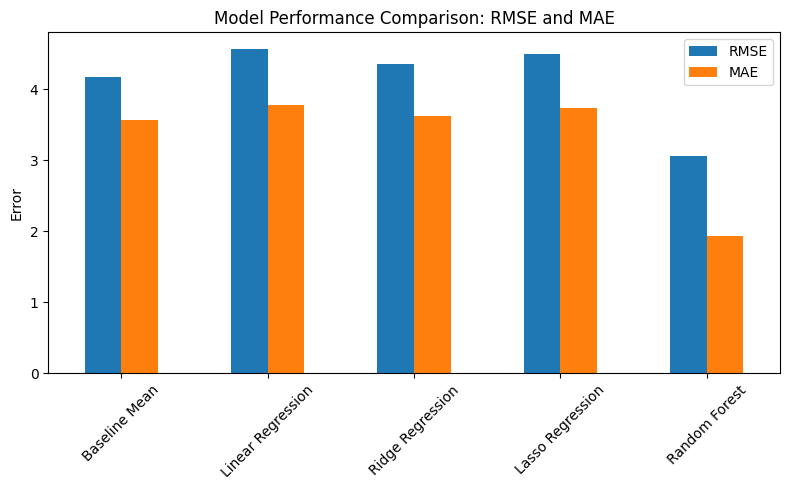

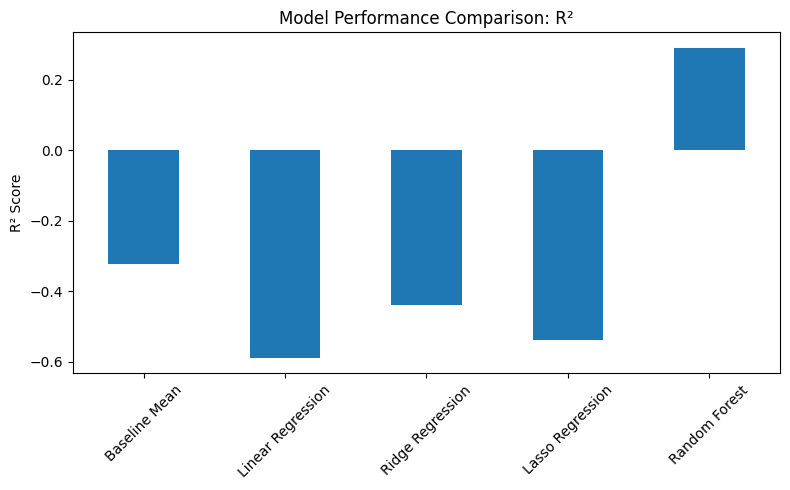

In [158]:
# RMSE, MAE 비교 그래프
results_df[['RMSE', 'MAE']].plot(kind='bar', figsize=(8, 5))
plt.title('Model Performance Comparison: RMSE and MAE')
plt.ylabel('Error')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# R² 비교 그래프
results_df['R²'].plot(kind='bar', figsize=(8, 5))
plt.title('Model Performance Comparison: R²')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [159]:
# 모델이 실패한 사례
error_df = X_test.copy()
error_df['Actual'] = y_test
error_df['Predicted'] = y_pred_rf
error_df['Absolute Error'] = abs(error_df['Actual'] - error_df['Predicted'])

error_df.sort_values(by='Absolute Error', ascending=False).head()

,Age,Current Weight,Daily Calories Consumed,Daily Caloric Surplus/Deficit,Duration,Stress Level,Gender_M,Physical Activity Level_Moderately Active,Physical Activity Level_Sedentary,Physical Activity Level_Very Active,Sleep Quality_Fair,Sleep Quality_Good,Sleep Quality_Poor,Actual,Predicted,Absolute Error
53,21,181.3,4000.0,1192.9,5,9,1.0,1.0,0.0,0.0,1.0,0.0,0.0,-1.135826,-10.430444,9.294617
70,57,100.0,2030.9,464.4,1,9,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.658347,-7.522558,5.864211
31,20,158.3,4000.0,1418.1,10,5,1.0,0.0,0.0,1.0,0.0,0.0,1.0,-2.203506,-6.679883,4.476376
44,37,184.5,3406.3,647.9,3,9,1.0,0.0,1.0,0.0,1.0,0.0,0.0,-4.988028,-9.400259,4.412231
77,58,198.8,3622.6,826.4,9,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,-4.378013,-8.073525,3.695513


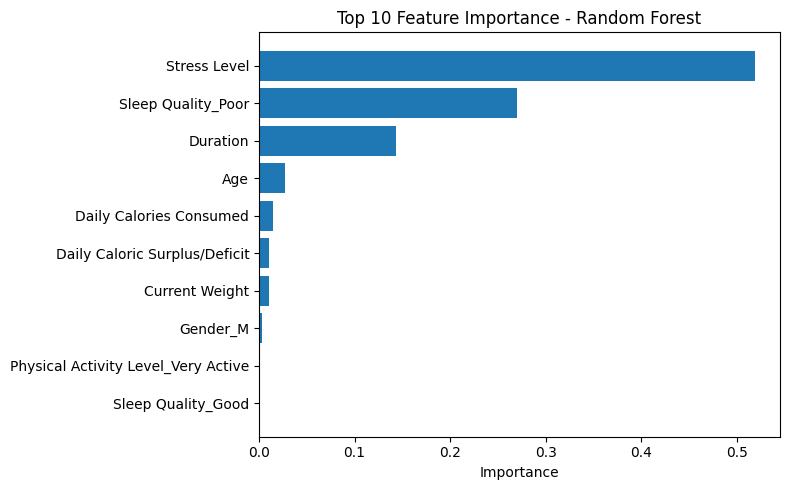

In [160]:
# Random Forest 중요 변수
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'].head(10), feature_importance['Importance'].head(10))
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()